# Machine Learning Exam - Football Matches

# Stage 1: Problem Foundation
## Hypothesis

### Regn (Samlet data pr. Kamp)
* Der scores flere mål i regnvejrskampe end tørvejrskampe
* Der bliver uddelt flere kort i regnvejrskampe vs tørvejr
* Bliver der generelt lavet flere “fouls” i en regnvejrskamp?
* Der bliver dømt flere straffespark i regnvejr end tørvejskampe

### Afleveringer og hjemmebanefordel (Individuel data pr. kamp)
* Højere afleveringsprocenter fører til flere mål end gennemsnittet
* Kampe er vundet med højere boldbesiddelse
* Kampe er vundet med flest skud på mål
* Man vinder oftere med hjemmebanefordel
* Hjemmebanehold får mindre “fouls” stemt imod sig end udebanehold

### Straffespark / Hjørnespark / Frispark (Individuel data pr. kamp)
* Mængden af kort et hold modtager har en korrelation til at man taber kampen
* Mængden af kort et hold modtager har en korrelation til at man vinder kampen
* Mængden af hjørnespark har en korrelation til at vinde kampe
* Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel

# Stage 2: Data Preparation And Exploration
## Data Collection
### Import data
Her importerer vi vores raw data vi har fået. Dataen er fodbold-kamp data fra perioden 2025-02-04 -3026-03-13

In [16]:
import pandas as pd
rawdf = pd.read_csv("data/matchdataraw.csv")
cleaneddf = rawdf.copy()
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,XGPERSHOT,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,0,0.077,20.7,0.8455,11,13,8,1,2,7,1,0,8,4,0,0,4,23,8,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
1,335,1699867,7499,12,8,4,0,0,0,28,2,0.083,22.6,0.9959,5,11,9,7,2,8,4,0,3,4,3,2,4,17,10,7,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
2,335,1699868,7456,5,14,2,0,1,2,19,0,0.069,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
3,335,1699868,7455,12,16,4,0,1,1,32,2,0.077,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
4,335,1699869,7460,14,10,4,0,1,0,38,3,0.097,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00.000,2015-07-19 10:30:00.000,Played,335,9493,4165479,1


## Cleaning
### Håndtering af NaN

In [17]:
cleaneddf.isnull().sum
cleaneddf.isna().sum()

COMPETITION_WYID           0
MATCH_WYID                 0
TEAM_WYID                  0
SHOTS                      0
FOULS                      0
CORNERS                    0
REDCARDS                   0
YELLOWCARDS                0
OFFSIDES                   0
DRIBBLES                   0
GOALS                      0
XGPERSHOT                  0
AVGDISTANCE                0
XG                         0
PROGRESSIVERUNS            0
TOUCHESINBOX               0
FOULSSUFFERED              0
SHOTSONTARGET              0
SHOTSBLOCKED               0
SHOTSOUTSIDEBOX            0
SHOTSOUTSIDEBOXONTARGET    0
SHOTSONPOST                0
SHOTSWIDE                  0
SHOTSFROMBOX               0
SHOTSFROMBOXONTARGET       0
FREEKICKS                  0
SHOTSFROMDANGERZONE        0
TOTALTHROWINS              0
LEFTTHROWINS               0
RIGHTTHROWINS              0
MATCH_WYID.1               0
MATCHLABEL                 0
DATE                       0
DATEUTC                    0
MATCHSTATUS   

### Håndtering af duplikeret rækker

In [18]:
cleaneddf.duplicated().sum()

np.int64(0)

### Håndtering af inkonsistente værdier (Danmark,DK)
  Vi fjerner "Expected goals per shot (XGPERSHOT)" pga. den er inkonsistent og der mangler data / forklaring på hvordan den laves korrekt

In [19]:
cleaneddf.drop(columns=["XGPERSHOT"], inplace=True)
print("XGPERSHOT i kolonner?", "XGPERSHOT" in cleaneddf.columns)

XGPERSHOT i kolonner? False


### Håndtering af outliers

Vi finder vores ekstreme outliers

In [20]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


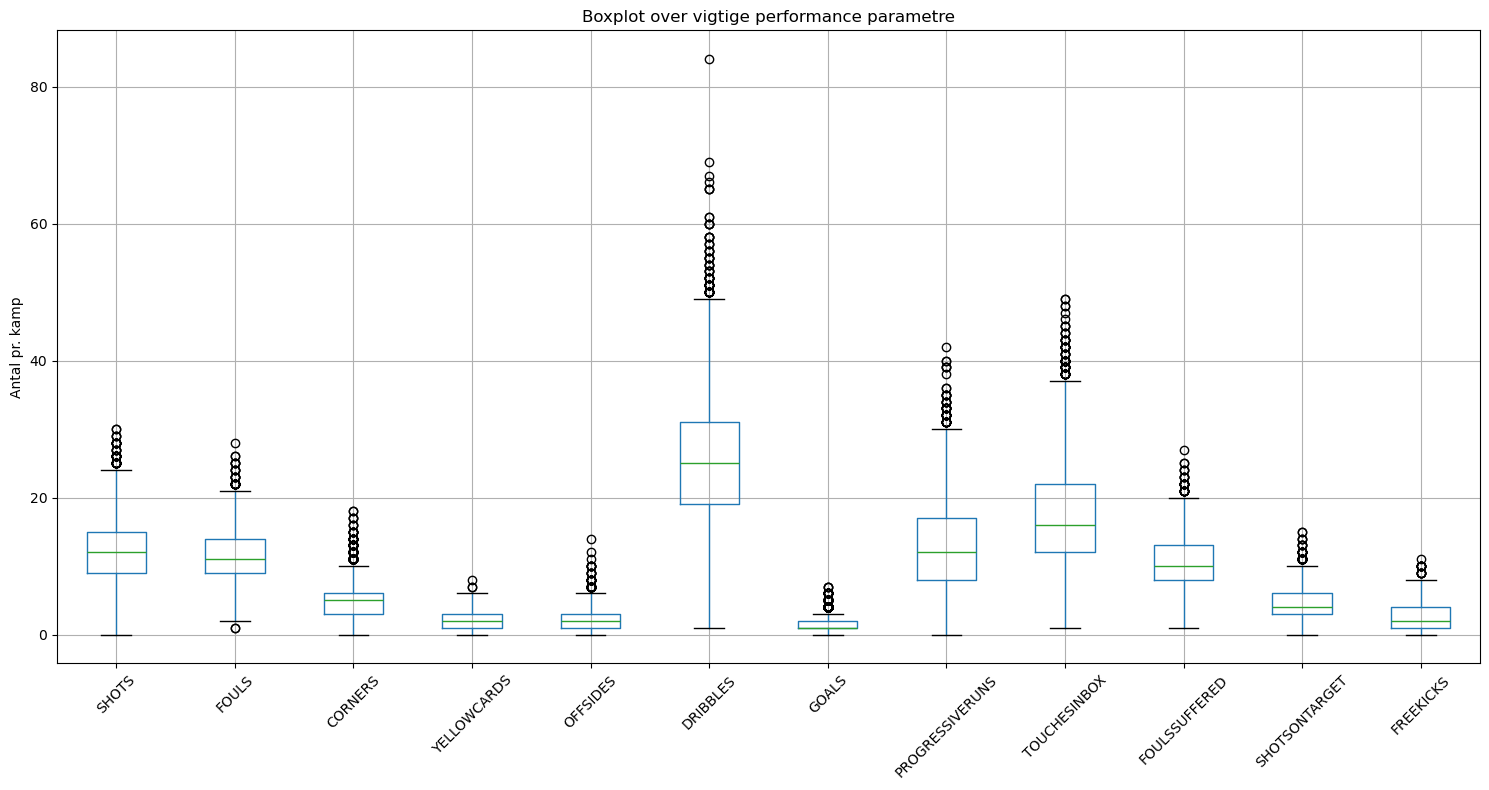

In [21]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

In [22]:
# Vi finder hvilken outlier der er ekstrem i dribbles kategorien
outliers = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers.head())

# Vi definerer en liste med alle de kamp-ID'er, vi vil ha fjernet
matches_to_remove = [1699867, 1699952, 2497370, 2720158, 2818322, 1699964]

# Vi sikrer at kolonnen er integer 
cleaneddf['MATCH_WYID'] = cleaneddf['MATCH_WYID'].astype(int)

# Vi fjerner listen
cleaneddf = cleaneddf[~cleaneddf['MATCH_WYID'].isin(matches_to_remove)]

# Vi dobbelt tjekker om de er blevet fjernet
outliers_check = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers_check.head())

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,0,20.7,0.8455,11,13,8,1,2,7,1,0,8,4,0,0,4,23,8,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
162,335,1699952,7457,10,9,6,0,1,1,67,1,23.5,0.3297,6,8,12,2,4,9,2,0,4,1,0,3,1,23,9,14,1699952,"Randers - AGF, 4 - 1",2015-11-06 19:30:00.000,2015-11-06 18:30:00.000,Played,335,9493,4165479,15
182,335,1699964,7456,11,17,6,0,1,3,65,1,21.5,0.9750,8,12,5,4,4,7,2,0,3,4,2,3,4,32,21,11,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
183,335,1699964,7457,10,7,3,0,1,2,84,0,24.3,0.3538,17,9,8,2,4,7,2,0,4,3,0,6,1,24,10,14,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
1107,335,2497370,7461,16,7,8,0,0,2,65,1,15.5,2.3040,11,22,15,4,7,4,0,0,5,12,4,5,7,36,10,26,2497370,"Silkeborg - Brøndby, 1 - 3",2017-11-26 18:00:00.000,2017-11-26 17:00:00.000,Played,335,181370,4405217,17


,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK


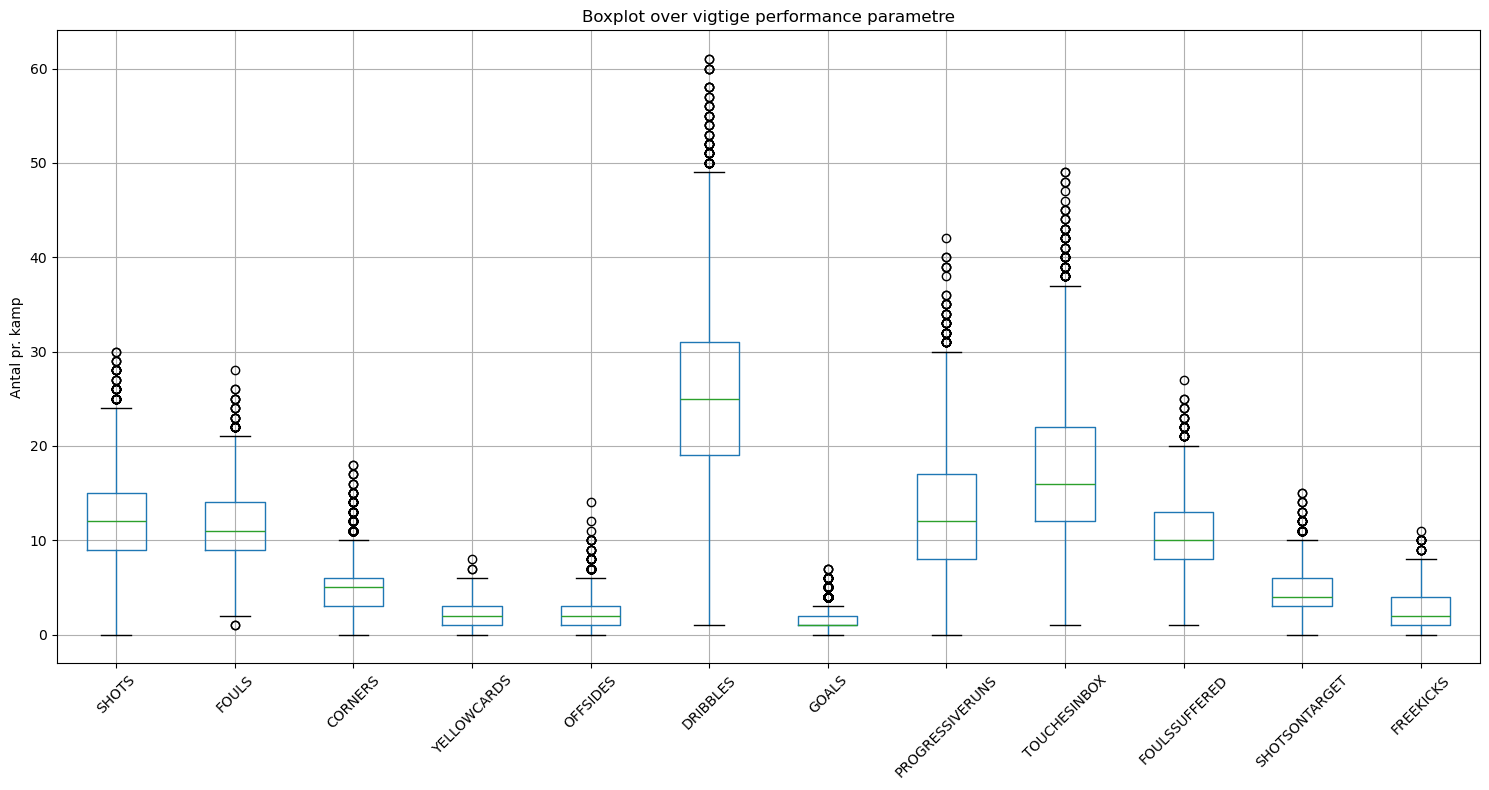

In [23]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

## Structering
### Vejr data

## Transformation
### Kategoriske værdier til numeriske

In [24]:
cleaneddf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   COMPETITION_WYID         4528 non-null   int64  
 1   MATCH_WYID               4528 non-null   int64  
 2   TEAM_WYID                4528 non-null   int64  
 3   SHOTS                    4528 non-null   int64  
 4   FOULS                    4528 non-null   int64  
 5   CORNERS                  4528 non-null   int64  
 6   REDCARDS                 4528 non-null   int64  
 7   YELLOWCARDS              4528 non-null   int64  
 8   OFFSIDES                 4528 non-null   int64  
 9   DRIBBLES                 4528 non-null   int64  
 10  GOALS                    4528 non-null   int64  
 11  AVGDISTANCE              4528 non-null   float64
 12  XG                       4528 non-null   float64
 13  PROGRESSIVERUNS          4528 non-null   int64  
 14  TOUCHESINBOX             4528

#### Vi vil gerne lave DATE og DATEUTC om til et datetime objekt

In [25]:
# Konverter DATE og DATEUTC til datetime-objekter
cleaneddf['DATE'] = pd.to_datetime(cleaneddf['DATE'])
cleaneddf['DATEUTC'] = pd.to_datetime(cleaneddf['DATEUTC'])

cleaneddf['weekday'] = cleaneddf['DATE'].dt.day_name() 

print(cleaneddf[['DATE', 'weekday']].head())
cleaneddf.info()

                 DATE   weekday
2 2015-07-18 15:00:00  Saturday
3 2015-07-18 15:00:00  Saturday
4 2015-07-19 12:30:00    Sunday
5 2015-07-19 12:30:00    Sunday
6 2015-07-19 17:00:00    Sunday
<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   COMPETITION_WYID         4528 non-null   int64         
 1   MATCH_WYID               4528 non-null   int64         
 2   TEAM_WYID                4528 non-null   int64         
 3   SHOTS                    4528 non-null   int64         
 4   FOULS                    4528 non-null   int64         
 5   CORNERS                  4528 non-null   int64         
 6   REDCARDS                 4528 non-null   int64         
 7   YELLOWCARDS              4528 non-null   int64         
 8   OFFSIDES                 4528 non-null   int64         
 9   DRIBBLES                 4528 

## Categorization

### Kategori med holdnavn og Kategori med nedbør ud fra vejrdata (nedbør mm)


In [26]:
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday
2,335,1699868,7456,5,14,2,0,1,2,19,0,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
3,335,1699868,7455,12,16,4,0,1,1,32,2,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
4,335,1699869,7460,14,10,4,0,1,0,38,3,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
5,335,1699869,7510,14,10,2,0,2,2,29,0,22.3,1.2890,3,12,9,9,2,8,6,1,2,6,3,1,3,27,14,13,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
6,335,1699871,7453,11,20,8,0,1,4,15,1,19.6,0.9837,2,19,10,2,5,4,2,0,4,7,0,4,4,24,13,11,1699871,"AGF - Brøndby, 2 - 1",2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday


In [27]:
import pandas as pd
import numpy as np

team_mapping = {
    7458: 'Nordsjælland', 7499: 'SønderjyskE', 7456: 'Viborg', 
    7455: 'Midtjylland', 7460: 'OB', 7510: 'Hobro', 
    7452: 'København', 7462: 'Randers', 7453: 'Brøndby', 
    7457: 'AGF', 7454: 'AaB', 7451: 'Esbjerg', 
    7484: 'Lyngby', 7461: 'Silkeborg', 7465: 'Horsens', 
    7566: 'FC Helsingør', 7488: 'Vendsyssel', 7473: 'Vejle', 
    7490: 'Hvidovre', 7469: 'Fredericia'
}

cleaneddf['TEAM_WYID'] = pd.to_numeric(cleaneddf['TEAM_WYID'], errors='coerce').fillna(0).astype(int)

cleaneddf['Hold'] = cleaneddf['TEAM_WYID'].map(team_mapping)

cleaneddf['Total Cards'] = pd.to_numeric(cleaneddf['REDCARDS'], errors='coerce').fillna(0) + \
                           pd.to_numeric(cleaneddf['YELLOWCARDS'], errors='coerce').fillna(0)

if 'MATCHLABEL' in cleaneddf.columns:
    matchlabel_data = cleaneddf.pop('MATCHLABEL')
    cleaneddf['MATCHLABEL'] = matchlabel_data

pd.set_option('display.max_columns', None)
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday,Hold,Total Cards,MATCHLABEL
2,335,1699868,7456,5,14,2,0,1,2,19,0,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Viborg,1,"Midtjylland - Viborg, 2 - 0"
3,335,1699868,7455,12,16,4,0,1,1,32,2,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Midtjylland,1,"Midtjylland - Viborg, 2 - 0"
4,335,1699869,7460,14,10,4,0,1,0,38,3,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,OB,1,"OB - Hobro, 3 - 0"
5,335,1699869,7510,14,10,2,0,2,2,29,0,22.3,1.2890,3,12,9,9,2,8,6,1,2,6,3,1,3,27,14,13,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,Hobro,2,"OB - Hobro, 3 - 0"
6,335,1699871,7453,11,20,8,0,1,4,15,1,19.6,0.9837,2,19,10,2,5,4,2,0,4,7,0,4,4,24,13,11,1699871,2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday,Brøndby,1,"AGF - Brøndby, 2 - 1"


## Total info
- Total Cards
- Total Shots
- Total Fouls
- Total Corners
- Total Red cards
- Total Yellow cards
- Total Off-side
- Total Dribbles
- Total Goals
- Total Progressive runs
- Total Free kicks
- Total Throw ins
- Total Rain (hvis vejrdata bliver implemeneteret)

Her samler vi kampene til en kamp. Så to rows bliver til en row der beskriver hele kampen

In [28]:
import pandas as pd
import numpy as np

cols_to_sum = {
    'SHOTS': 'Total Shots',
    'FOULS': 'Total Fouls',
    'CORNERS': 'Total Corners',
    'REDCARDS': 'Total Red cards',
    'YELLOWCARDS': 'Total Yellow cards',
    'OFFSIDES': 'Total Off-side',
    'DRIBBLES': 'Total Dribbles',
    'GOALS': 'Total Goals',
    'PROGRESSIVERUNS': 'Total Progressive runs',
    'FREEKICKS': 'Total Free kicks',
    'TOTALTHROWINS': 'Total Throw ins'
}


match_df = cleaneddf.groupby(['MATCH_WYID', 'MATCHLABEL']).agg({
    **{col: 'sum' for col in cols_to_sum.keys()}
}).reset_index()

match_df.rename(columns=cols_to_sum, inplace=True)

match_df['Total Cards'] = match_df['Total Red cards'] + match_df['Total Yellow cards']

pd.set_option('display.max_columns', None)
match_df.head()

,MATCH_WYID,MATCHLABEL,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards
0,1699868,"Midtjylland - Viborg, 2 - 0",17,30,6,0,2,3,51,2,16,17,52,2
1,1699869,"OB - Hobro, 3 - 0",28,20,6,0,3,2,67,3,14,1,45,3
2,1699870,"København - Randers, 3 - 0",20,29,6,0,3,2,73,3,12,3,51,3
3,1699871,"AGF - Brøndby, 2 - 1",21,30,11,0,3,6,30,3,4,6,38,3
4,1699872,"AaB - Esbjerg, 1 - 1",36,25,15,0,4,2,52,2,13,1,44,4


### Rettelse af enkelte grammatik-fejl

In [29]:
cleaneddf = cleaneddf.replace("SønderjyskE", "Sønderjyske")
match_df = match_df.replace("SønderjyskE", "Sønderjyske")

# Check om ændringen er gået igennem
print((cleaneddf == "SønderjyskE").any().any())
print((match_df == "SønderjyskE").any().any())

False
False


### Rettelse af MATCHLABEL til HOMETEAM, AWAYTEAM, HOMEGOAL, AWAYGOAL

In [30]:
# Split hold og score: 
match_df[['Teams', 'Score']] = match_df['MATCHLABEL'].str.rsplit(', ', n=1, expand=True)

In [31]:
# Split hjemmhold og udehold:
match_df[['Home Team', 'Away Team']] = match_df['Teams'].str.split(' - ', expand=True)

In [32]:
# Split scoreline i hjemmemål og udemål
match_df[['Home Goals', 'Away Goals']] = match_df['Score'].str.split('-', expand=True)


In [33]:
# Check om ændringen er gået igennem
match_df[['Teams', 'Score','Home Team','Away Team','Home Goals','Away Goals']].head()

,Teams,Score,Home Team,Away Team,Home Goals,Away Goals
0,Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0
1,OB - Hobro,3 - 0,OB,Hobro,3,0
2,København - Randers,3 - 0,København,Randers,3,0
3,AGF - Brøndby,2 - 1,AGF,Brøndby,2,1
4,AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1


In [34]:
# Reorder df:
cols = [
    'MATCH_WYID','MATCHLABEL','Teams','Score','Home Team','Away Team','Home Goals','Away Goals',
    'Total Shots','Total Fouls','Total Corners','Total Red cards','Total Yellow cards',
    'Total Off-side','Total Dribbles','Total Goals','Total Progressive runs',
    'Total Free kicks','Total Throw ins','Total Cards'
]

match_df = match_df[cols]

In [35]:
match_df.head()

,MATCH_WYID,MATCHLABEL,Teams,Score,Home Team,Away Team,Home Goals,Away Goals,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards
0,1699868,"Midtjylland - Viborg, 2 - 0",Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0,17,30,6,0,2,3,51,2,16,17,52,2
1,1699869,"OB - Hobro, 3 - 0",OB - Hobro,3 - 0,OB,Hobro,3,0,28,20,6,0,3,2,67,3,14,1,45,3
2,1699870,"København - Randers, 3 - 0",København - Randers,3 - 0,København,Randers,3,0,20,29,6,0,3,2,73,3,12,3,51,3
3,1699871,"AGF - Brøndby, 2 - 1",AGF - Brøndby,2 - 1,AGF,Brøndby,2,1,21,30,11,0,3,6,30,3,4,6,38,3
4,1699872,"AaB - Esbjerg, 1 - 1",AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1,36,25,15,0,4,2,52,2,13,1,44,4


## Validation
Data er valideret og cleaned. Ingen missing values eller nonsens værdier

### Vi har to dataframes

#### cleaneddf 
Her opstår der kampe hvor der er to rækker for hver ene kamp. Hver række er fra hvert hold der spillede i den ene kamp. Der er tilføjet en kolonne helt ude til højre, som fortæller hvilket hold rækken tilhøre

#### match_df
Her er de to rækker merged sammen i en, hvor hele rækken viser total value for hele kampen


# Stage 3: Data Modeling

In [37]:
from dmi_utils import hent_vejr


In [38]:
TEAM_MUNICIPALITY = {"København":"0101","Brøndby":"0153","Nordsjælland":"0217","Lyngby":"0173","FC Helsingør":"0217","Hvidovre":"0167","OB":"0461","Esbjerg":"0561","SønderjyskE":"0540","Sønderjyske":"0540","AaB":"0851","Vendsyssel":"0813","Hobro":"0846","Midtjylland":"0657","AGF":"0751","Viborg":"0791","Horsens":"0615","Fredericia":"0607","Vejle":"0630","Randers":"0730","Silkeborg":"0740"}
dato_map = cleaneddf.groupby('MATCH_WYID').agg(DATE=('DATE','first'), MATCHLABEL=('MATCHLABEL','first')).reset_index()
dato_map['home_team'] = dato_map['MATCHLABEL'].str.split(',').str[0].str.split(' - ').str[0].str.strip()
dato_map['municipality_id'] = dato_map['home_team'].map(TEAM_MUNICIPALITY)
dato_map['dato_str'] = dato_map['DATE'].dt.strftime('%Y-%m-%d')
print("Hold uden mapping:", dato_map[dato_map['municipality_id'].isna()]['home_team'].unique())
unikke = dato_map[dato_map['municipality_id'].notna()][['dato_str','municipality_id']].drop_duplicates().reset_index(drop=True)
print(f"Unikke dato+kommune kombinationer: {len(unikke)}")

Hold uden mapping: []
Unikke dato+kommune kombinationer: 2263


In [39]:
vejr_df = hent_vejr(unikke, cache_path="data/vejr_cache.csv")
print(vejr_df.head())

Henter 2263 kombinationer fra DMI...
Gemt — 2263 ud af 2263 dage fik data
     dato_str municipality_id  nedbor_mm
0  2015-07-18            0657        8.0
1  2015-07-19            0461        0.2
2  2015-09-16            0101        0.0
3  2015-07-19            0751        0.1
4  2015-07-20            0851        4.7


In [40]:
match_df_vejr = match_df.copy()

In [41]:
dato_map2 = dato_map[['MATCH_WYID','dato_str','municipality_id']].merge(vejr_df, on=['dato_str','municipality_id'], how='left')
match_df_vejr = match_df_vejr.merge(dato_map2[['MATCH_WYID','nedbor_mm']], on='MATCH_WYID', how='left')
match_df_vejr['Total Regn'] = match_df_vejr['nedbor_mm']
match_df_vejr['Regnede'] = match_df_vejr['Total Regn'] > 0
match_df_vejr.drop(columns=['nedbor_mm'], inplace=True)
print(match_df_vejr['Regnede'].value_counts())

Regnede
True     1290
False     974
Name: count, dtype: int64


In [42]:
print(match_df_vejr.groupby('Regnede')[['Total Goals','Total Yellow cards','Total Red cards','Total Fouls','Total Free kicks']].mean().round(2))

         Total Goals  Total Yellow cards  Total Red cards  Total Fouls  \
Regnede                                                                  
False           2.81                3.69             0.15        22.37   
True            2.84                3.63             0.14        22.61   

         Total Free kicks  
Regnede                    
False                4.98  
True                 5.08  


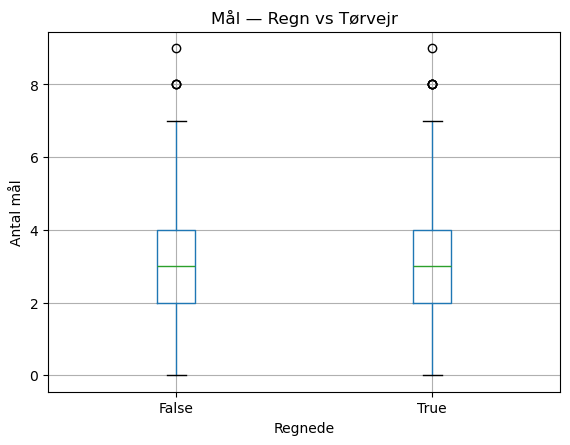

In [43]:
match_df_vejr.boxplot(column='Total Goals', by='Regnede')
plt.title('Mål — Regn vs Tørvejr')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal mål')
plt.show()

In [44]:
from scipy import stats
regn = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Goals']
torr = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Goals']
t, p = stats.ttest_ind(regn, torr)
print(f"Gennemsnit regn:     {regn.mean():.2f} mål")
print(f"Gennemsnit tørvejr:  {torr.mean():.2f} mål")
print(f"T-test p-værdi:      {p:.4f}")
print(f"Konklusion: {' SIGNIFIKANT forskel' if p < 0.05 else ' INGEN signifikant forskel'}")

Gennemsnit regn:     2.84 mål
Gennemsnit tørvejr:  2.81 mål
T-test p-værdi:      0.7139
Konklusion:  INGEN signifikant forskel


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = match_df_vejr[['Total Goals']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))
print(f"Koefficient for mål: {lr.coef_[0][0]:.4f}")

              precision    recall  f1-score   support

           0       0.36      0.44      0.40       180
           1       0.57      0.49      0.53       273

    accuracy                           0.47       453
   macro avg       0.47      0.47      0.46       453
weighted avg       0.49      0.47      0.48       453

Koefficient for mål: 0.0269


In [46]:
print("=" * 50)
print("HYPOTESE: Flere mål i regnvejr end tørvejr")
print("=" * 50)
print(f"Gennemsnit regn:       {regn.mean():.2f} mål")
print(f"Gennemsnit tørvejr:    {torr.mean():.2f} mål")
print(f"T-test p-værdi:        {p:.4f}")
print(f"Logistisk R. accuracy: {lr.score(X_test, y_test):.2f}")
print(f"Koefficient:           {lr.coef_[0][0]:.4f}")
print()
print("KONKLUSION: Hypotesen afkræftes")
print("=" * 50)

HYPOTESE: Flere mål i regnvejr end tørvejr
Gennemsnit regn:       2.84 mål
Gennemsnit tørvejr:    2.81 mål
T-test p-værdi:        0.7139
Logistisk R. accuracy: 0.47
Koefficient:           0.0269

KONKLUSION: Hypotesen afkræftes


In [47]:
print(match_df_vejr.groupby('Regnede')[['Total Yellow cards','Total Red cards']].mean().round(2))

         Total Yellow cards  Total Red cards
Regnede                                     
False                  3.69             0.15
True                   3.63             0.14


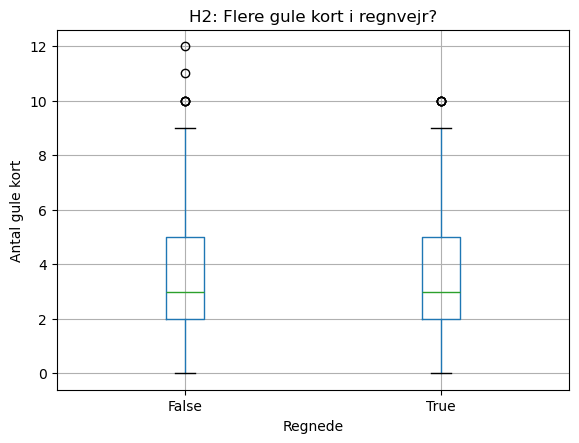

In [48]:
match_df_vejr.boxplot(column='Total Yellow cards', by='Regnede')
plt.title('H2: Flere gule kort i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal gule kort')
plt.show()

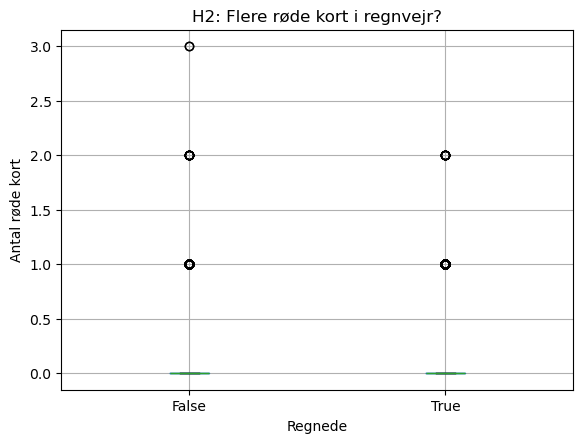

In [49]:
match_df_vejr.boxplot(column='Total Red cards', by='Regnede')
plt.title('H2: Flere røde kort i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal røde kort')
plt.show()

In [50]:
regn_gule = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Yellow cards']
torr_gule = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Yellow cards']
t, p_gule = stats.ttest_ind(regn_gule, torr_gule)
regn_rode = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Red cards']
torr_rode = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Red cards']
t, p_rode = stats.ttest_ind(regn_rode, torr_rode)
print(f"Gule kort — regn: {regn_gule.mean():.2f}  tørvejr: {torr_gule.mean():.2f}  p={p_gule:.4f} → {' SIGNIFIKANT' if p_gule < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Røde kort — regn: {regn_rode.mean():.2f}  tørvejr: {torr_rode.mean():.2f}  p={p_rode:.4f} → {' SIGNIFIKANT' if p_rode < 0.05 else ' IKKE SIGNIFIKANT'}")

Gule kort — regn: 3.63  tørvejr: 3.69  p=0.4220 →  IKKE SIGNIFIKANT
Røde kort — regn: 0.14  tørvejr: 0.15  p=0.5603 →  IKKE SIGNIFIKANT


In [51]:
X = match_df_vejr[['Total Yellow cards','Total Red cards']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.38      0.86      0.53       180
           1       0.44      0.07      0.13       273

    accuracy                           0.39       453
   macro avg       0.41      0.47      0.33       453
weighted avg       0.42      0.39      0.29       453



In [52]:
print("=" * 50)
print("H2: Flere kort i regnvejr end tørvejr?")
print("=" * 50)
print(f"Gule kort — regn: {regn_gule.mean():.2f}  tørvejr: {torr_gule.mean():.2f}  p={p_gule:.4f} → {' SIGNIFIKANT' if p_gule < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Røde kort — regn: {regn_rode.mean():.2f}  tørvejr: {torr_rode.mean():.2f}  p={p_rode:.4f} → {' SIGNIFIKANT' if p_rode < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Logistisk regression accuracy: {lr.score(X_test, y_test):.2f}")
print()
print("KONKLUSION:  Hypotesen afkræftes")
print("Hverken gule eller røde kort påvirkes af regn")
print("=" * 50)

H2: Flere kort i regnvejr end tørvejr?
Gule kort — regn: 3.63  tørvejr: 3.69  p=0.4220 →  IKKE SIGNIFIKANT
Røde kort — regn: 0.14  tørvejr: 0.15  p=0.5603 →  IKKE SIGNIFIKANT
Logistisk regression accuracy: 0.39

KONKLUSION:  Hypotesen afkræftes
Hverken gule eller røde kort påvirkes af regn


In [53]:
print(match_df_vejr.groupby('Regnede')[['Total Fouls']].mean().round(2))

         Total Fouls
Regnede             
False          22.37
True           22.61


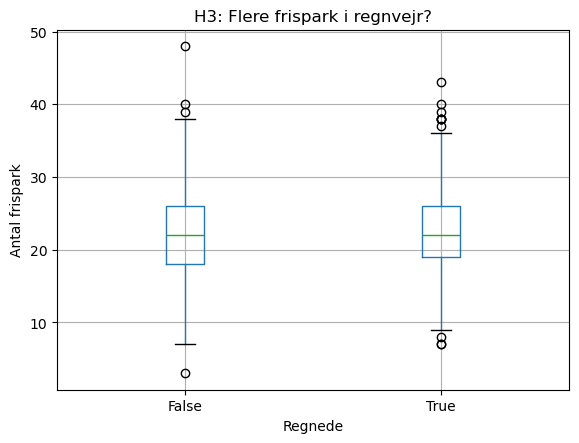

In [54]:
match_df_vejr.boxplot(column='Total Fouls', by='Regnede')
plt.title('H3: Flere frispark i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal frispark')
plt.show()

In [55]:
regn_fouls = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Fouls']
torr_fouls = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Fouls']
t, p_fouls = stats.ttest_ind(regn_fouls, torr_fouls)
print(f"Frispark — regn: {regn_fouls.mean():.2f}  tørvejr: {torr_fouls.mean():.2f}  p={p_fouls:.4f} → {' SIGNIFIKANT' if p_fouls < 0.05 else ' IKKE SIGNIFIKANT'}")

Frispark — regn: 22.61  tørvejr: 22.37  p=0.3022 →  IKKE SIGNIFIKANT


In [56]:
X = match_df_vejr[['Total Fouls']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.41      0.52      0.46       180
           1       0.62      0.51      0.56       273

    accuracy                           0.51       453
   macro avg       0.51      0.51      0.51       453
weighted avg       0.54      0.51      0.52       453



In [57]:
print("=" * 50)
print("H3: Flere frispark i regnvejr end tørvejr?")
print("=" * 50)
print(f"Frispark — regn: {regn_fouls.mean():.2f}  tørvejr: {torr_fouls.mean():.2f}  p={p_fouls:.4f} → {' SIGNIFIKANT' if p_fouls < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Logistisk regression accuracy: {lr.score(X_test, y_test):.2f}")
print()
print("KONKLUSION:  Hypotesen BEKRÆFTET" if p_fouls < 0.05 else "KONKLUSION:  Hypotesen afkræftes")
print("=" * 50)

H3: Flere frispark i regnvejr end tørvejr?
Frispark — regn: 22.61  tørvejr: 22.37  p=0.3022 →  IKKE SIGNIFIKANT
Logistisk regression accuracy: 0.51

KONKLUSION:  Hypotesen afkræftes


In [58]:
print(match_df_vejr.groupby('Regnede')[['Total Free kicks']].mean().round(2))

         Total Free kicks
Regnede                  
False                4.98
True                 5.08


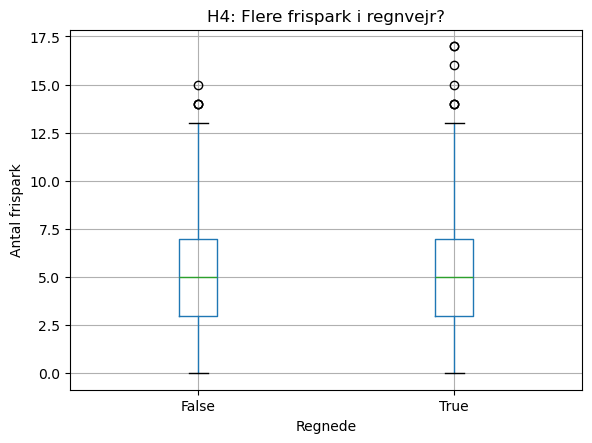

In [59]:
match_df_vejr.boxplot(column='Total Free kicks', by='Regnede')
plt.title('H4: Flere frispark i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal frispark')
plt.show()

In [60]:
regn_frispark = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Free kicks']
torr_frispark = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Free kicks']
t, p_frispark = stats.ttest_ind(regn_frispark, torr_frispark)
print(f"Frispark — regn: {regn_frispark.mean():.2f}  tørvejr: {torr_frispark.mean():.2f}  p={p_frispark:.4f} → {' SIGNIFIKANT' if p_frispark < 0.05 else ' IKKE SIGNIFIKANT'}")

Frispark — regn: 5.08  tørvejr: 4.98  p=0.3441 →  IKKE SIGNIFIKANT


In [61]:
X = match_df_vejr[['Total Free kicks']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.40      0.61      0.49       180
           1       0.61      0.41      0.49       273

    accuracy                           0.49       453
   macro avg       0.51      0.51      0.49       453
weighted avg       0.53      0.49      0.49       453



In [62]:
print("=" * 50)
print("H4: Flere frispark i regnvejr end tørvejr?")
print("=" * 50)
print(f"Frispark — regn: {regn_frispark.mean():.2f}  tørvejr: {torr_frispark.mean():.2f}  p={p_frispark:.4f} → {' SIGNIFIKANT' if p_frispark < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Logistisk regression accuracy: {lr.score(X_test, y_test):.2f}")
print()
print("KONKLUSION: Hypotesen BEKRÆFTET" if p_frispark < 0.05 else "KONKLUSION:  Hypotesen afkræftes")
print("=" * 50)

H4: Flere frispark i regnvejr end tørvejr?
Frispark — regn: 5.08  tørvejr: 4.98  p=0.3441 →  IKKE SIGNIFIKANT
Logistisk regression accuracy: 0.49

KONKLUSION:  Hypotesen afkræftes


In [63]:
print("=" * 50)
print("SAMLET KONKLUSION — VEJR VS FODBOLD")
print("=" * 50)
print("Ingen af de 4 hypoteser kunne bekræftes.")
print("Regn har ingen statistisk signifikant effekt")
print("på mål, kort, fouls eller frikick i")
print("dansk Superliga 2015-2026.")
print("=" * 50)

SAMLET KONKLUSION — VEJR VS FODBOLD
Ingen af de 4 hypoteser kunne bekræftes.
Regn har ingen statistisk signifikant effekt
på mål, kort, fouls eller frikick i
dansk Superliga 2015-2026.


In [64]:
match_df_vejr.head()

,MATCH_WYID,MATCHLABEL,Teams,Score,Home Team,Away Team,Home Goals,Away Goals,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards,Total Regn,Regnede
0,1699868,"Midtjylland - Viborg, 2 - 0",Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0,17,30,6,0,2,3,51,2,16,17,52,2,8.0,True
1,1699869,"OB - Hobro, 3 - 0",OB - Hobro,3 - 0,OB,Hobro,3,0,28,20,6,0,3,2,67,3,14,1,45,3,0.2,True
2,1699870,"København - Randers, 3 - 0",København - Randers,3 - 0,København,Randers,3,0,20,29,6,0,3,2,73,3,12,3,51,3,0.0,False
3,1699871,"AGF - Brøndby, 2 - 1",AGF - Brøndby,2 - 1,AGF,Brøndby,2,1,21,30,11,0,3,6,30,3,4,6,38,3,0.1,True
4,1699872,"AaB - Esbjerg, 1 - 1",AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1,36,25,15,0,4,2,52,2,13,1,44,4,4.7,True
